# K-Means Clustering

Let's import the packages that we will use during the practical:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

##  The dataset

As the first step, we need to import data from `retail_dataset.csv` using `read_csv()` function from `pandas` (`pd`). We also want to define the column that we are going to use as the row labels of the dataframe: *CustomerID*. Once loaded, we can apply `head()` function to preview the first five rows of our dataframe. 

In [2]:
# Import the data from the retail_dataset.csv

customers_data = pd.read_csv('data/retail_dataset.csv', index_col='CustomerID')
customers_data.head()

,Austria,Belgium,Finland,France,Germany,Italy,Norway,Portugal,Spain,Switzerland,...,balance,max_spent,mean_spent,min_spent,n_orders,total_items,total_items_returned,total_refunded,total_spent,has_returned
CustomerID,,,,,,,,,,,,,,,,,,,,,
12348,0,0,1,0,0,0,0,0,0,0,...,0.383285,1.250693,1.431525,0.513598,-0.134499,2.257327,0.177632,0.250957,0.375547,False
12350,0,0,0,0,0,0,1,0,0,0,...,-0.555081,-0.636253,-0.573046,0.022799,-0.695840,-0.522217,0.177632,0.250957,-0.557665,True
12352,0,0,0,0,0,0,1,0,0,0,...,-0.148636,0.097227,-0.374642,-0.760775,0.426842,-0.281712,-1.054751,-1.146316,-0.122088,False
12354,0,0,0,0,0,0,0,0,1,0,...,-0.349333,0.121654,1.005066,2.112152,-0.695840,-0.383240,0.177632,0.250957,-0.353048,True
12356,0,0,0,0,0,0,0,1,0,0,...,1.103279,3.917886,5.490954,3.525167,-0.415170,1.249951,0.177632,0.250957,1.091586,False


We will start by looking specifically at the numerical features. Below we list non-binary features and separate them into a dataframe called `customers`:

In [3]:
non_binary_cols = [
    'balance', 'max_spent', 'mean_spent', 
    'min_spent', 'n_orders','total_items', 
    'total_refunded', 'total_spent']

customers = customers_data[non_binary_cols]
customers.head()

,balance,max_spent,mean_spent,min_spent,n_orders,total_items,total_refunded,total_spent
CustomerID,,,,,,,,
12348,0.383285,1.250693,1.431525,0.513598,-0.134499,2.257327,0.250957,0.375547
12350,-0.555081,-0.636253,-0.573046,0.022799,-0.695840,-0.522217,0.250957,-0.557665
12352,-0.148636,0.097227,-0.374642,-0.760775,0.426842,-0.281712,-1.146316,-0.122088
12354,-0.349333,0.121654,1.005066,2.112152,-0.695840,-0.383240,0.250957,-0.353048
12356,1.103279,3.917886,5.490954,3.525167,-0.415170,1.249951,0.250957,1.091586


## Clustering with K-Means

K-Means clustering is a method for finding clusters and cluster centroids (the centre point of a cluster) in a set of points. The K-Means algorithm is quite simple and alternates between two steps:

1. For each centroid, identify the subset of training points that are closer to it than to any other centroid.
2. Update the location of the centroid to match the points related to it.

These two steps are repeated until the centroids no longer move (significantly) or the assignments no longer change. Then a new point $x$ can be assigned to the nearest cluster.

### Run K-Means with two features

Isolate the features `mean_spent` and `max_spent`, then run the K-Means algorithm on the resulting dataset using $k=2$ and visualise the result. You will need:

* to create an instance of `KMeans` with 2 clusters,
* fit this to the isolated features (via the `.fit` method),
* look how it is doing by showing the assignment predicted (via the `.predict` method).

This is the standard `sklearn` workflow for most of the algorithms.

In [6]:
from sklearn.cluster import KMeans

cust2  = customers[['mean_spent', 'max_spent']]
# Apply K-Means with 2 clusters using a subset of features 
# (mean_spent and max_spent)

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(cust2)




,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [7]:
#store the cluster assignment
cluster_assignment = kmeans.predict(cust2)

Let's introduce a simple function to better visualise what is going on:

In [8]:
# This function generates a pairplot enhanced with the result of K-Means
def pairplot_cluster(df, cols, cluster_assignment):
    """
    Input
        df, dataframe that contains the data to plot
        cols, columns to consider for the plot
        cluster_assignments, cluster asignment returned 
        by the clustering algorithm
    """
    # seaborn will color the samples according to the column cluster
    df_tmp = df.copy() # create a copy so we don't modify the original dataframe
    df_tmp['cluster'] = cluster_assignment 
    sns.pairplot(df_tmp, vars=cols, hue='cluster')

Let's use the method now to see how we did previously (ignore the warnings if anything comes up):

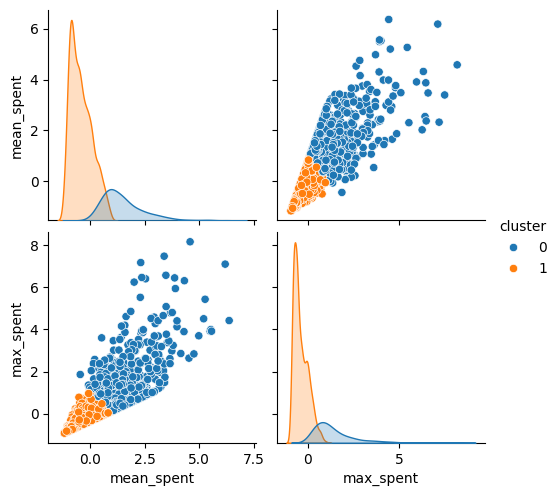

In [10]:
# Visualise the clusters using pairplot_cluster()
pairplot_cluster(customers, ['mean_spent', 'max_spent'], cluster_assignment)


#### What can you observe?

* The separation between the two clusters is "clean" (the two clusters can be separated with a line).
* One cluster contains customers with low spendings, the other one with high spendings.

### Run K-Means with all the features
Run K-Means using all the features available and visualise the result in the subspace of `mean_spent` and `max_spent`.

In [19]:
# Apply K-Means with 2 clusters using all features
kmeans= KMeans(n_clusters=2, random_state=0)
kmeans.fit(customers)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
cluster_assignment = kmeans.predict(customers)

Visualise the cluster assignment using the same subset of variables as before. What has changed?

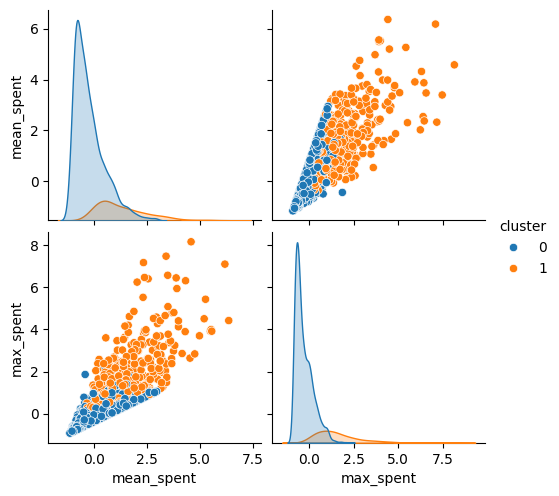

In [21]:
# Visualise the clusters using pairplot_cluster()
pairplot_cluster(customers, ['mean_spent', 'max_spent'], cluster_assignment)


***Question***: Why can't the clusters be separated with a line as before?

### Compare expenditure between clusters

Select the features `mean_spent` and `max_spent` and compare the two clusters obtained above using them.

In [22]:
# Compare expenditure between clusters
features = ['mean_spent', 'max_spent']

# create a dataframe corresponding to the case
# cluster_assignment == 0
cluster1_df = pd.DataFrame(data=customers[cluster_assignment == 0], 
                           columns=customers.columns)[features]

cluster1_desc = cluster1_df.describe()

In [23]:
# then with cluster_assignment == 1
cluster2_df = pd.DataFrame(data=customers[cluster_assignment == 1], 
                           columns=customers.columns)[features]

cluster2_desc = cluster2_df.describe()

In [24]:
# Join both
compare_df = cluster1_desc.join(cluster2_desc, lsuffix='_cluster1', rsuffix='_cluster2')
compare_df

,mean_spent_cluster1,max_spent_cluster1,mean_spent_cluster2,max_spent_cluster2
count,2627.000000,2627.000000,499.000000,499.000000
mean,-0.246314,-0.307733,1.296726,1.620072
std,0.727273,0.497599,1.217832,1.357207
min,-1.164888,-0.920492,-0.682826,-0.348837
25%,-0.806033,-0.691840,0.391314,0.681795
50%,-0.446923,-0.466366,0.980874,1.312890
75%,0.098405,-0.025269,1.944119,2.136092
max,2.944977,2.247712,6.362242,8.150460


### Look at the centroids

Look at the centroids of the clusters by calling `kmeans.cluster_centers_` and check the values of the centroids for the features `mean_spent`, `max_spent`. You will need to create a new dataframe where the data is simply `kmeans.cluster_centers_`.

In [29]:
# Get the centroids and display them
centers_df = pd.DataFrame(data=kmeans.cluster_centers_, columns=customers.columns)
print(centers_df[features])


   mean_spent  max_spent
0   -0.246314  -0.307733
1    1.296726   1.620072


### Compare mean expediture with box plot

Compare the distribution of the feature `mean_spent` in the two clusters using a box plot. You will need:

* `sns.boxplot` (seaborn's boxplot)

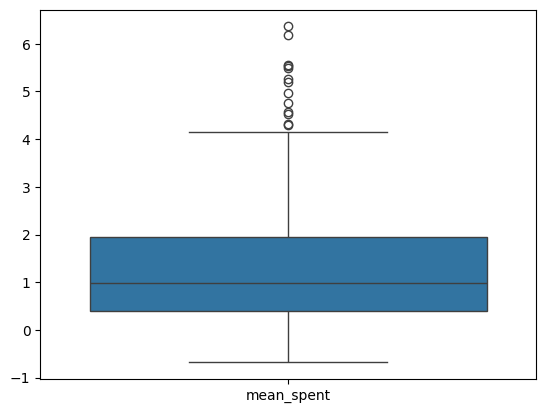

In [30]:
# Compare mean expediture with box plot

#plt.figure(figsize = (10,6))
sns.boxplot(data=[cluster1_df.mean_spent, cluster2_df.mean_spent])
plt.show()


Does this seem to make sense? How can you interpret the plots?

### Look at the inertia
Inertia measures the internal coherence of clusters. You can look at the inertia easily by calling ``kmeans.inertia_``:

In [32]:
# Look at the inertia
print('Inertia: {0:.2f}'.format(kmeans.inertia_))


Inertia: 15302.11


The value of inertia on its own does not say much as it is not normalized. However, it can be used for selecting a suitable number of clusters as part of the elbow method.

In elbow method, we first calculate inertia for clusterings with different numbers of clusters. We then choose the number with the largest change in rate of decline as explained in the lecture.

### Compute the silhouette score
Compute the silhouette score of the clusters resulting from the application of K-Means.

The score represents how similar a sample is to the samples in its own cluster compared to samples in other clusters. The best value is 1, while the worst value is -1. Values close to 0 suggest overlapping clusters. Negative values occur when a sample is assigned to the wrong cluster (a different cluster is more similar).

`sklearn` provides the function `silhouette_score`, which you can call and display.

In [ ]:
from sklearn.metrics import silhouette_score

# Computing the silhouette score

print('Silhouette score: {0:.2f}'.format(silhouette_score(customers, cluster_assignment)))


Silhouette Score: 0.58
Silhouette score: 0.58


This silhouette score is reasonably high, which we can interpret by saying that the corresponding clusters are quite compact.

### Finding the optimal number of clusters

Try plotting the inertia and silhouette score for different numbers of clusters (e.g. between 1 and 20)

Note that silhouette score can only be calculated for two or more clusters.

In [39]:
k_vals = [i + 1 for i in range(20)]
silhouette_scores = []
inertias = []

# calculate the scores
for k in k_vals:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(customers)
    cluster_assignment = kmeans.labels_
    if k>1:
        silhouette_scores.append(silhouette_score(customers, cluster_assignment))
    else:
        silhouette_scores.append(None)
    inertias.append(kmeans.inertia_)
    
print(f'Silhoutte scores: {silhouette_scores} \n\n Intertias {inertias}')

Silhoutte scores: [None, 0.5766888120787835, 0.4586304120809576, 0.4863702316265538, 0.4928312659732492, 0.3945057321589814, 0.4054296588616533, 0.4083146487693286, 0.4111201371871902, 0.3896915864648133, 0.33254254865514105, 0.3970710534925247, 0.33570972751162675, 0.3428471279479353, 0.3346748976311646, 0.3414375071306921, 0.3427788459275465, 0.3393966395424176, 0.3414056507914433, 0.3348707391716518] 

 Intertias [25007.999999999993, 15302.113119321648, 12156.274271686052, 9582.44969116477, 7987.3118168008405, 8008.5008952874505, 6422.404294462749, 5951.890247296942, 5544.010193211447, 5037.103339336073, 4596.353589348719, 4417.567444233555, 4174.182293593954, 3998.220748425415, 3820.523325701255, 3579.676313186555, 3410.329327684236, 3316.0004381590697, 3339.1420549999807, 3149.60331401485]


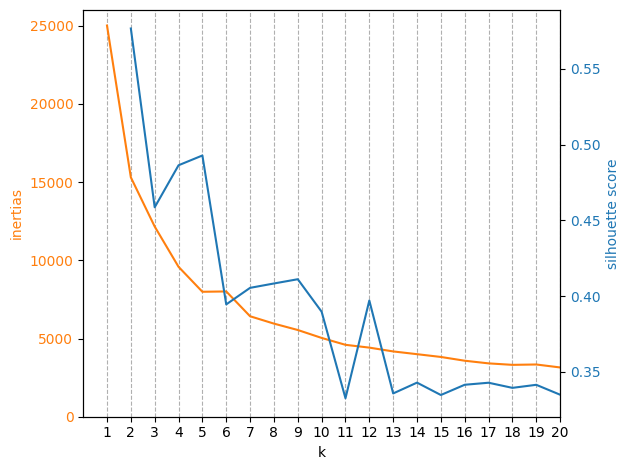

In [40]:
fig, ax1 = plt.subplots()

color = 'tab:orange'
ax1.set_xlabel('k')
ax1.set_ylabel('inertias', color=color)
ax1.plot(k_vals, inertias, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(0,20)
ax1.set_xticks(k_vals)
ax1.set_ylim(0,26000)
ax1.grid(visible=True, axis='x', linestyle='--')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('silhouette score', color=color) #  we already handled the x-label with ax1
ax2.plot(k_vals, silhouette_scores, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()